In [20]:
import cv2
import os
import numpy as np
import pandas as pd
import zipfile
from datetime import datetime


In [21]:
import cv2
print(cv2.__version__)
print(hasattr(cv2, "face"))

5.0.0
True


In [22]:
import zipfile
import os

zip_path = "face_dataset.zip"
extract_folder = "dataset"

if not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_folder)
    print("Dataset extracted successfully!")
else:
    print("Dataset already exists!")

Dataset already exists!


In [23]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset\.ipynb_checkpoints
dataset\dataset
dataset\dataset\Dataset
dataset\dataset\Dataset\Faces
dataset\dataset\Dataset\Faces\Akshay Kumar
dataset\dataset\Dataset\Faces\Alexandra Daddario
dataset\dataset\Dataset\Faces\Alia Bhatt
dataset\dataset\Dataset\Faces\Amitabh Bachchan
dataset\dataset\Dataset\Faces\Andy Samberg
dataset\dataset\Dataset\Faces\Anushka Sharma
dataset\dataset\Dataset\Faces\Billie Eilish
dataset\dataset\Dataset\Faces\Brad Pitt
dataset\dataset\Dataset\Faces\Camila Cabello
dataset\dataset\Dataset\Faces\Charlize Theron
dataset\dataset\Dataset\Faces\Claire Holt
dataset\dataset\Dataset\Faces\Courtney Cox
dataset\dataset\Dataset\Faces\Dwayne Johnson
dataset\dataset\Dataset\Faces\Elizabeth Olsen
dataset\dataset\Dataset\Faces\Ellen Degeneres
dataset\dataset\Dataset\Faces\Henry Cavill
dataset\dataset\Dataset\Faces\Hrithik Roshan
dataset\dataset\Dataset\Faces\Hugh Jackman
dataset\dataset\Dataset\Faces\Jessica Alba
dataset\dataset\Dataset\Faces\Kashyap
dataset\dataset\Da

In [24]:
import os
import cv2
import numpy as np

dataset_path = "dataset/dataset/Dataset/Faces"

faces = []
ids = []
names = {}

person_id = 0

for person_name in sorted(os.listdir(dataset_path)):

    person_folder = os.path.join(dataset_path, person_name)

    if os.path.isdir(person_folder):

        person_id += 1
        names[person_id] = person_name

        for image_name in os.listdir(person_folder):

            image_path = os.path.join(person_folder, image_name)

            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                continue

            faces.append(image)
            ids.append(person_id)

print("Total Persons :", len(names))
print("Total Images  :", len(faces))

print("\nPerson IDs:")
for key, value in names.items():
    print(key, ":", value)

Total Persons : 31
Total Images  : 1483

Person IDs:
1 : Akshay Kumar
2 : Alexandra Daddario
3 : Alia Bhatt
4 : Amitabh Bachchan
5 : Andy Samberg
6 : Anushka Sharma
7 : Billie Eilish
8 : Brad Pitt
9 : Camila Cabello
10 : Charlize Theron
11 : Claire Holt
12 : Courtney Cox
13 : Dwayne Johnson
14 : Elizabeth Olsen
15 : Ellen Degeneres
16 : Henry Cavill
17 : Hrithik Roshan
18 : Hugh Jackman
19 : Jessica Alba
20 : Kashyap
21 : Lisa Kudrow
22 : Margot Robbie
23 : Marmik
24 : Natalie Portman
25 : Priyanka Chopra
26 : Robert Downey Jr
27 : Roger Federer
28 : Tom Cruise
29 : Vijay Deverakonda
30 : Virat Kohli
31 : Zac Efron


In [28]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

recognizer.train(
    faces,
    np.array(ids)
)

recognizer.write("trainer.yml")

print("Model trained successfully!")
print("trainer.yml saved.")

Model trained successfully!
trainer.yml saved.


In [30]:


recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("trainer.yml")

face_detector = cv2.CascadeClassifier(
    "haarcascade_frontalface_default.xml"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [31]:
import os

print(os.getcwd())

C:\Users\jhana\smart_attendence_system_using_face_recignition


In [32]:


dataset_path = "dataset/dataset/Dataset/Faces"

names = {}

person_id = 0

for person_name in sorted(os.listdir(dataset_path)):
    person_folder = os.path.join(dataset_path, person_name)

    if os.path.isdir(person_folder):
        person_id += 1
        names[person_id] = person_name

print(names)

{1: 'Akshay Kumar', 2: 'Alexandra Daddario', 3: 'Alia Bhatt', 4: 'Amitabh Bachchan', 5: 'Andy Samberg', 6: 'Anushka Sharma', 7: 'Billie Eilish', 8: 'Brad Pitt', 9: 'Camila Cabello', 10: 'Charlize Theron', 11: 'Claire Holt', 12: 'Courtney Cox', 13: 'Dwayne Johnson', 14: 'Elizabeth Olsen', 15: 'Ellen Degeneres', 16: 'Henry Cavill', 17: 'Hrithik Roshan', 18: 'Hugh Jackman', 19: 'Jessica Alba', 20: 'Kashyap', 21: 'Lisa Kudrow', 22: 'Margot Robbie', 23: 'Marmik', 24: 'Natalie Portman', 25: 'Priyanka Chopra', 26: 'Robert Downey Jr', 27: 'Roger Federer', 28: 'Tom Cruise', 29: 'Vijay Deverakonda', 30: 'Virat Kohli', 31: 'Zac Efron'}


In [33]:


face_detector = cv2.CascadeClassifier(
    "haarcascade_frontalface_default.xml"
)

print("Cascade Loaded:", not face_detector.empty())

Cascade Loaded: True


In [34]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

recognizer.read("trainer.yml")

print("Recognizer Loaded Successfully")

Recognizer Loaded Successfully


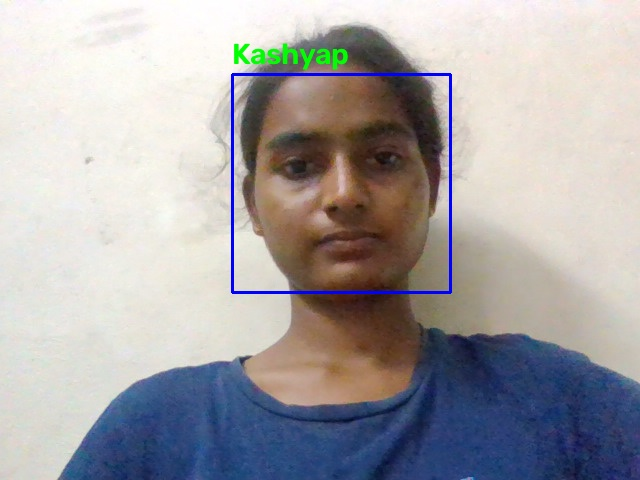

Final Attendance:
[['Kashyap', '2026-07-27 23:15:25'], ['Dwayne Johnson', '2026-07-27 23:15:25']]


In [36]:

from IPython.display import display, Image, clear_output
import cv2

attendance = []

camera = cv2.VideoCapture(0, cv2.CAP_MSMF)

if not camera.isOpened():
    print("Cannot open camera")

for i in range(50):

    ret, frame = camera.read()

    if not ret:
        print("Cannot read frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:

        person_id, confidence = recognizer.predict(
            gray[y:y+h, x:x+w]
        )

        print("ID:", person_id, "Confidence:", confidence)

        if confidence < 70 and person_id in names:

            name = names[person_id]

            # Add attendance only once
            already_marked = False

            for person in attendance:
                if person[0] == name:
                    already_marked = True
                    break

            if not already_marked:
                attendance.append([
                    name,
                    datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                ])

        else:
            name = "Unknown"


        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (255, 0, 0),
            2
        )

        cv2.putText(
            frame,
            name,
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

    cv2.imwrite("result.jpg", frame)

    clear_output(wait=True)
    display(Image("result.jpg"))


camera.release()
cv2.destroyAllWindows()

print("Final Attendance:")
print(attendance)

In [37]:
import pandas as pd

attendance_df = pd.DataFrame(
    attendance,
    columns=["Name", "Time"]
)

attendance_df.to_csv(
    "attendance.csv",
    index=False
)

print("Attendance saved successfully!")

Attendance saved successfully!


In [38]:


pd.read_csv("attendance.csv")

,Name,Time
0,Kashyap,2026-07-27 23:15:25
1,Dwayne Johnson,2026-07-27 23:15:25
